# Image Classification of Landfill Waste
**DS 4002 — Project 3 | Corner Data Co.**  
Patrick Yin (Group Leader), Margot Brady, Tarana Ahad  


## 0. Install & Import Dependencies

In [1]:
#Install packages

!pip install torch torchvision matplotlib seaborn scikit-learn tqdm Pillow

In [2]:
import os
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm

#Ensure Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 1. Configuration

In [3]:
# ── Update DATA_DIR to the root folder of the downloaded RealWaste dataset
# Expected folder structure:
#   DATA_DIR/
#     Cardboard/
#     Food Organics/
#     Glass/
#     Metal/
#     Miscellaneous Trash/
#     Paper/
#     Plastic/
#     Textile Trash/
#     Vegetation/


DATA_DIR = '../DATA/realwaste-main/RealWaste'
OUTPUTS_DIR = '../OUTPUTS'

IMG_SIZE        = 224
BATCH_SIZE      = 32
NUM_CLASSES     = 9
EPOCHS_HEAD     = 5       # Phase 1: train classification head only
EPOCHS_FINETUNE = 10      # Phase 2: fine-tune top layers
LR_HEAD         = 1e-3
LR_FINETUNE     = 1e-4

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

CLASS_NAMES = [
    'Cardboard', 'Food Organics', 'Glass', 'Metal',
    'Miscellaneous Trash', 'Paper', 'Plastic',
    'Textile Trash', 'Vegetation'
]



## 2. Step 1 — Data Preparation
Resize, normalize, and split into 70 / 15 / 15 train / val / test sets.

In [4]:
# ImageNet mean/std — used because all three backbones were pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Augmentation applied to training set only
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Load the full dataset once (no augmentation) for indexing / splitting
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform)
print(f'Total images  : {len(full_dataset)}')
print(f'Classes found : {full_dataset.classes}')

Total images  : 4752
Classes found : ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


In [5]:
# Stratified 70 / 15 / 15 split
all_indices = list(range(len(full_dataset)))
all_labels  = [full_dataset.targets[i] for i in all_indices]

train_idx, temp_idx = train_test_split(
    all_indices, test_size=(1 - TRAIN_RATIO),
    stratify=all_labels, random_state=SEED
)
temp_labels = [full_dataset.targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5,
    stratify=temp_labels, random_state=SEED
)

print(f'Train : {len(train_idx)} images')
print(f'Val   : {len(val_idx)}   images')
print(f'Test  : {len(test_idx)}  images')

Train : 3326 images
Val   : 713   images
Test  : 713  images


In [6]:
# Apply augmentation only to the training subset
train_dataset_aug = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)

train_subset = Subset(train_dataset_aug, train_idx)
val_subset   = Subset(full_dataset,      val_idx)
test_subset  = Subset(full_dataset,      test_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_subset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('DataLoaders ready.')

DataLoaders ready.


## 3. Exploratory Data Analysis

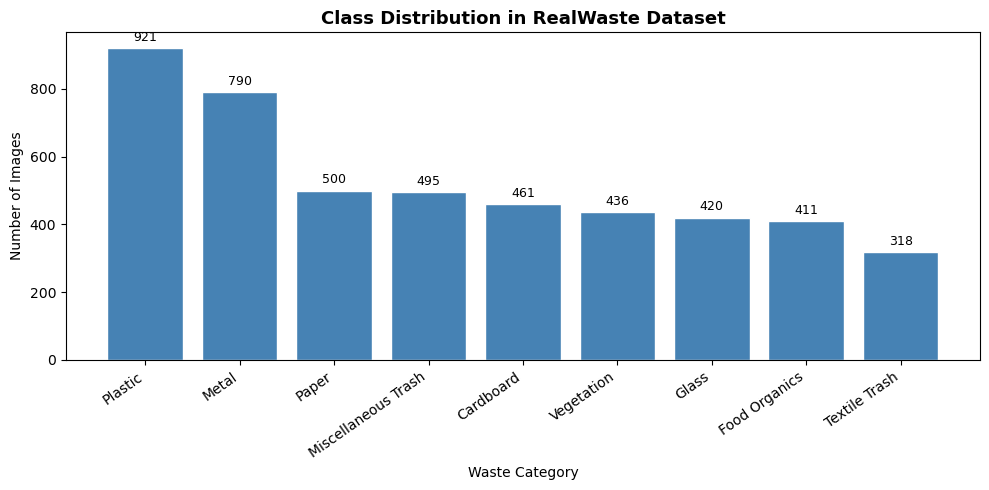

Total images: 4752


In [7]:
# Class distribution
label_counts   = Counter(full_dataset.targets)
sorted_counts  = dict(sorted(label_counts.items(), key=lambda x: x[1], reverse=True))
class_labels   = [full_dataset.classes[k] for k in sorted_counts]
counts         = list(sorted_counts.values())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_labels, counts, color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Class Distribution in RealWaste Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Waste Category')
ax.set_ylabel('Number of Images')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print(f'Total images: {sum(counts)}')

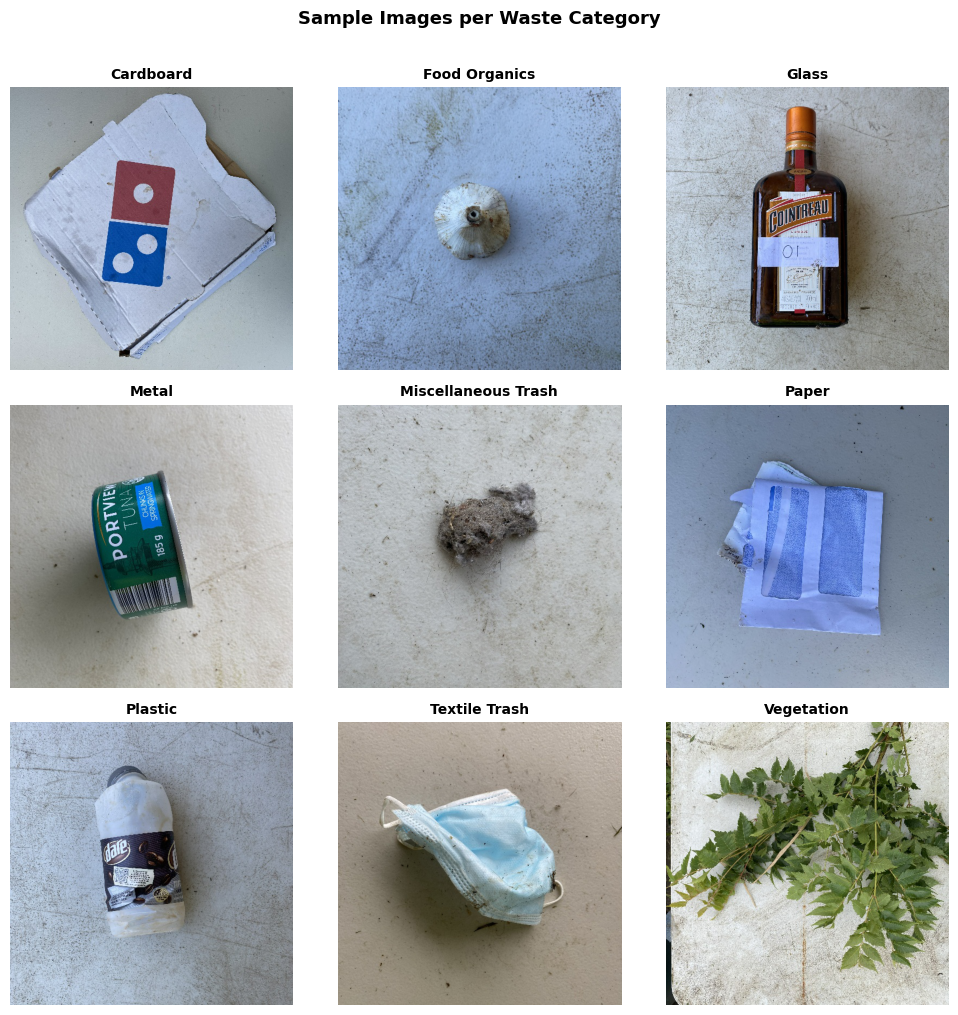

In [8]:
# One sample image per class
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for class_idx, ax in enumerate(axes):
    class_name = full_dataset.classes[class_idx]
    class_dir  = os.path.join(DATA_DIR, class_name)
    img_file   = random.choice(os.listdir(class_dir))
    img = plt.imread(os.path.join(class_dir, img_file))
    ax.imshow(img)
    ax.set_title(class_name, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Images per Waste Category', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'sample_images.png'), dpi=150)
plt.show()

## 4. Step 2 — Class Imbalance: Weighted Cross-Entropy Loss

In [9]:
# Compute class weights
train_labels         = [full_dataset.targets[i] for i in train_idx]
class_counts         = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
class_weights        = 1.0 / class_counts
class_weights        = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print('Class weights (higher = more underrepresented):')
for name, w in zip(CLASS_NAMES, class_weights):
    print(f'  {name:<25}: {w:.4f}')

Class weights (higher = more underrepresented):
  Cardboard                : 1.0374
  Food Organics            : 1.1635
  Glass                    : 1.1397
  Metal                    : 0.6059
  Miscellaneous Trash      : 0.9685
  Paper                    : 0.9574
  Plastic                  : 0.5195
  Textile Trash            : 1.5094
  Vegetation               : 1.0986


## 5. Step 3 — Model Definitions (Transfer Learning)

In [10]:
def build_mobilenet_v3_small(num_classes=NUM_CLASSES):
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model

def build_efficientnet_b0(num_classes=NUM_CLASSES):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

def build_resnet50(num_classes=NUM_CLASSES):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

MODEL_BUILDERS = {
    'MobileNetV3-Small': build_mobilenet_v3_small,
    'EfficientNet-B0'  : build_efficientnet_b0,
    'ResNet-50'        : build_resnet50,
}

print('Model builders defined.')

Model builders defined.


## 6. Training Utilities

In [11]:
def freeze_backbone(model, model_name):
    """Freeze all layers except the final classification head."""
    for param in model.parameters():
        param.requires_grad = False
    if model_name == 'MobileNetV3-Small':
        for param in model.classifier[3].parameters():
            param.requires_grad = True
    elif model_name == 'EfficientNet-B0':
        for param in model.classifier[1].parameters():
            param.requires_grad = True
    elif model_name == 'ResNet-50':
        for param in model.fc.parameters():
            param.requires_grad = True

def unfreeze_top_layers(model, model_name):
    """Unfreeze top feature blocks for fine-tuning."""
    if model_name == 'MobileNetV3-Small':
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True
    elif model_name == 'EfficientNet-B0':
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True
    elif model_name == 'ResNet-50':
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

def run_epoch(model, loader, criterion, optimizer=None, phase='train'):
    """Run one epoch; return (loss, accuracy)."""
    is_train = phase == 'train'
    model.train(is_train)
    running_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in tqdm(loader, desc=phase, leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * images.size(0)
            preds   = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return running_loss / total, correct / total

def train_model(model, model_name, criterion, train_loader, val_loader,
                epochs_head=EPOCHS_HEAD, epochs_finetune=EPOCHS_FINETUNE,
                lr_head=LR_HEAD, lr_finetune=LR_FINETUNE):
    """Two-phase training: head-only, then top-layer fine-tuning."""
    model = model.to(DEVICE)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # Phase 1: classification head only
    print(f'\n{"="*60}')
    print(f'  {model_name} — Phase 1: Training Classification Head')
    print(f'{"="*60}')
    freeze_backbone(model, model_name)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr_head)
    for epoch in range(1, epochs_head + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, 'train')
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, phase='val')
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        print(f'  Epoch {epoch:>2}/{epochs_head}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    # Phase 2: fine-tune top layers
    print(f'\n  {model_name} — Phase 2: Fine-Tuning Top Layers')
    print(f'{"="*60}')
    unfreeze_top_layers(model, model_name)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr_finetune)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    best_val_acc, best_weights = 0.0, None
    for epoch in range(1, epochs_finetune + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, 'train')
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, phase='val')
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        print(f'  Epoch {epoch:>2}/{epochs_finetune}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    print(f'\n  Best val accuracy: {best_val_acc:.4f}')
    return model, history

print('Training utilities defined.')

Training utilities defined.


## 7. Train All Three Models

In [12]:
trained_models     = {}
training_histories = {}

for model_name, builder in MODEL_BUILDERS.items():
    model = builder()
    trained_model, history = train_model(
        model, model_name, criterion, train_loader, val_loader
    )
    trained_models[model_name]     = trained_model
    training_histories[model_name] = history
    save_path = f"{model_name.replace(' ', '_').replace('-', '')}_best.pth"
    torch.save(trained_model.state_dict(), save_path)
    print(f'  Checkpoint saved: {save_path}\n')


  MobileNetV3-Small — Phase 1: Training Classification Head


train:   0%|          | 0/104 [00:00<?, ?it/s]c:\Users\patri\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Epoch  1/5  train_loss=1.4309  train_acc=0.5105  val_loss=0.9850  val_acc=0.6732


  Epoch  2/5  train_loss=0.9869  train_acc=0.6624  val_loss=0.8146  val_acc=0.7237


  Epoch  3/5  train_loss=0.8567  train_acc=0.6891  val_loss=0.7478  val_acc=0.7447


...

  Epoch  6/10  train_loss=0.0918  train_acc=0.9708  val_loss=0.2432  val_acc=0.9285


  Epoch  7/10  train_loss=0.0652  train_acc=0.9768  val_loss=0.2615  val_acc=0.9215


  Epoch  8/10  train_loss=0.0641  train_acc=0.9784  val_loss=0.2796  val_acc=0.9299


  Epoch  9/10  train_loss=0.0508  train_acc=0.9835  val_loss=0.2533  val_acc=0.9355


  Epoch 10/10  train_loss=0.0449  train_acc=0.9874  val_loss=0.2436  val_acc=0.9271

  Best val accuracy: 0.9355
  Checkpoint saved: ResNet50_best.pth



## 8. Training Curves

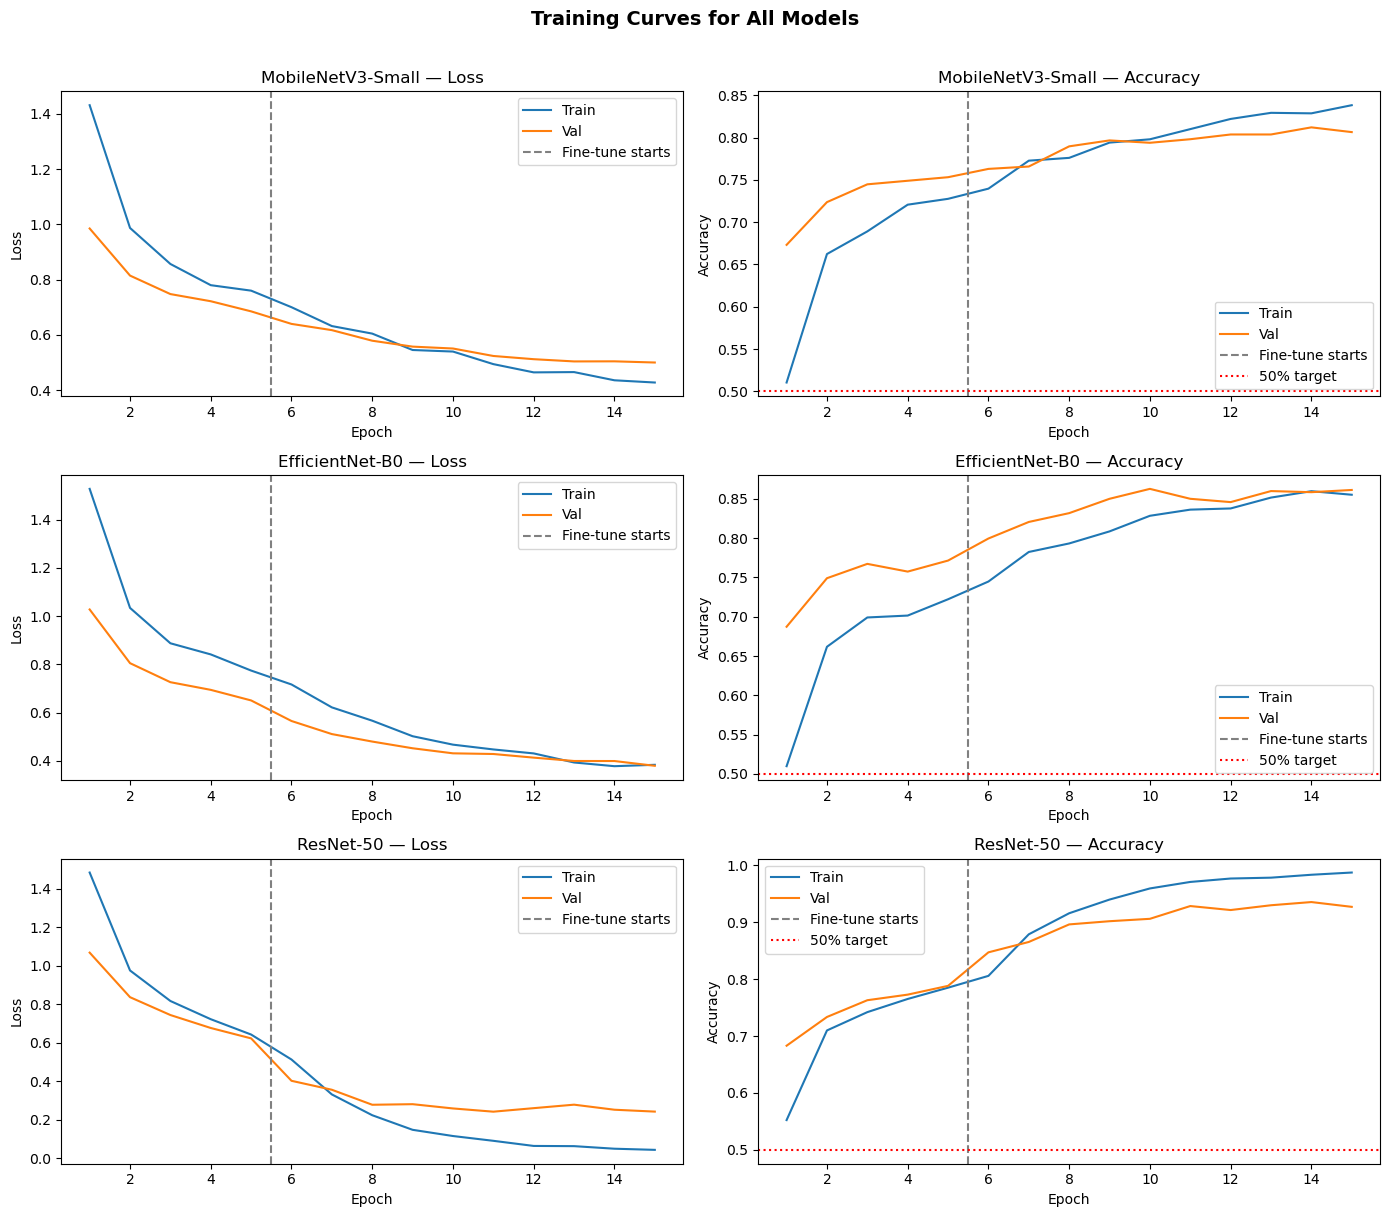

In [13]:
fig, axes = plt.subplots(len(trained_models), 2, figsize=(14, 4 * len(trained_models)))

for row, (model_name, hist) in enumerate(training_histories.items()):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax_loss, ax_acc = axes[row, 0], axes[row, 1]

    ax_loss.plot(epochs, hist['train_loss'], label='Train')
    ax_loss.plot(epochs, hist['val_loss'],   label='Val')
    ax_loss.axvline(EPOCHS_HEAD + 0.5, color='gray', linestyle='--', label='Fine-tune starts')
    ax_loss.set_title(f'{model_name} — Loss')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend()

    ax_acc.plot(epochs, hist['train_acc'], label='Train')
    ax_acc.plot(epochs, hist['val_acc'],   label='Val')
    ax_acc.axvline(EPOCHS_HEAD + 0.5, color='gray', linestyle='--', label='Fine-tune starts')
    ax_acc.axhline(0.5, color='red', linestyle=':', label='50% target')
    ax_acc.set_title(f'{model_name} — Accuracy')
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()

plt.suptitle('Training Curves for All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 9. Step 4 — Model Evaluation on Test Set

In [14]:
def evaluate_model(model, loader, model_name):
    model.eval()
    all_preds, all_labels = [], []
    total_time, total_images = 0.0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f'Evaluating {model_name}'):
            images = images.to(DEVICE)
            t0 = time.perf_counter()
            outputs = model(images)
            t1 = time.perf_counter()
            total_time   += (t1 - t0)
            total_images += images.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
    avg_ms = (total_time / total_images) * 1000
    return all_preds, all_labels, avg_ms

results = {}
for model_name, model in trained_models.items():
    preds, labels, speed = evaluate_model(model, test_loader, model_name)
    macro_f1 = f1_score(labels, preds, average='macro')
    accuracy = np.mean(np.array(preds) == np.array(labels))
    results[model_name] = {'preds': preds, 'labels': labels,
                           'macro_f1': macro_f1, 'accuracy': accuracy, 'speed_ms': speed}
    print(f'\n{model_name}')
    print(f'  Accuracy       : {accuracy:.4f}')
    print(f'  Macro F1 Score : {macro_f1:.4f}')
    print(f'  Avg speed      : {speed:.3f} ms/image')

Evaluating MobileNetV3-Small: 100%|██████████| 23/23 [00:08<00:00,  2.57it/s]



MobileNetV3-Small
  Accuracy       : 0.8135
  Macro F1 Score : 0.8240
  Avg speed      : 1.840 ms/image


Evaluating EfficientNet-B0:   0%|          | 0/23 [00:00<?, ?it/s]c:\Users\patri\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Evaluating EfficientNet-B0: 100%|██████████| 23/23 [00:13<00:00,  1.68it/s]



EfficientNet-B0
  Accuracy       : 0.8387
  Macro F1 Score : 0.8469
  Avg speed      : 10.520 ms/image


Evaluating ResNet-50:   0%|          | 0/23 [00:00<?, ?it/s]c:\Users\patri\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Evaluating ResNet-50: 100%|██████████| 23/23 [00:30<00:00,  1.33s/it]


ResNet-50
  Accuracy       : 0.8934
  Macro F1 Score : 0.9009
  Avg speed      : 34.315 ms/image


### 9a. Per-Class Classification Reports

In [15]:
report_path = os.path.join(OUTPUTS_DIR, 'classification_reports.txt')
with open(report_path, 'w') as f:
    for model_name, res in results.items():
        header = f'\n{"="*60}\n  {model_name}\n{"="*60}\n'
        report = classification_report(res['labels'], res['preds'], target_names=CLASS_NAMES)
        f.write(header + report)
        print(header + report)
print(f'Classification reports saved to {report_path}')


  MobileNetV3-Small
                     precision    recall  f1-score   support

          Cardboard       0.84      0.88      0.86        69
      Food Organics       0.80      0.89      0.84        62
              Glass       0.84      0.83      0.83        63
              Metal       0.75      0.85      0.80       118
Miscellaneous Trash       0.73      0.63      0.68        75
              Paper       0.86      0.79      0.82        75
            Plastic       0.79      0.72      0.75       138
      Textile Trash       0.81      0.92      0.86        48
         Vegetation       0.98      0.97      0.98        65

           accuracy                           0.81       713
          macro avg       0.82      0.83      0.82       713
       weighted avg       0.81      0.81      0.81       713


  EfficientNet-B0
                     precision    recall  f1-score   support

          Cardboard       0.84      0.88      0.86        69
      Food Organics       0.92      0.89 

### 9b. Confusion Matrices

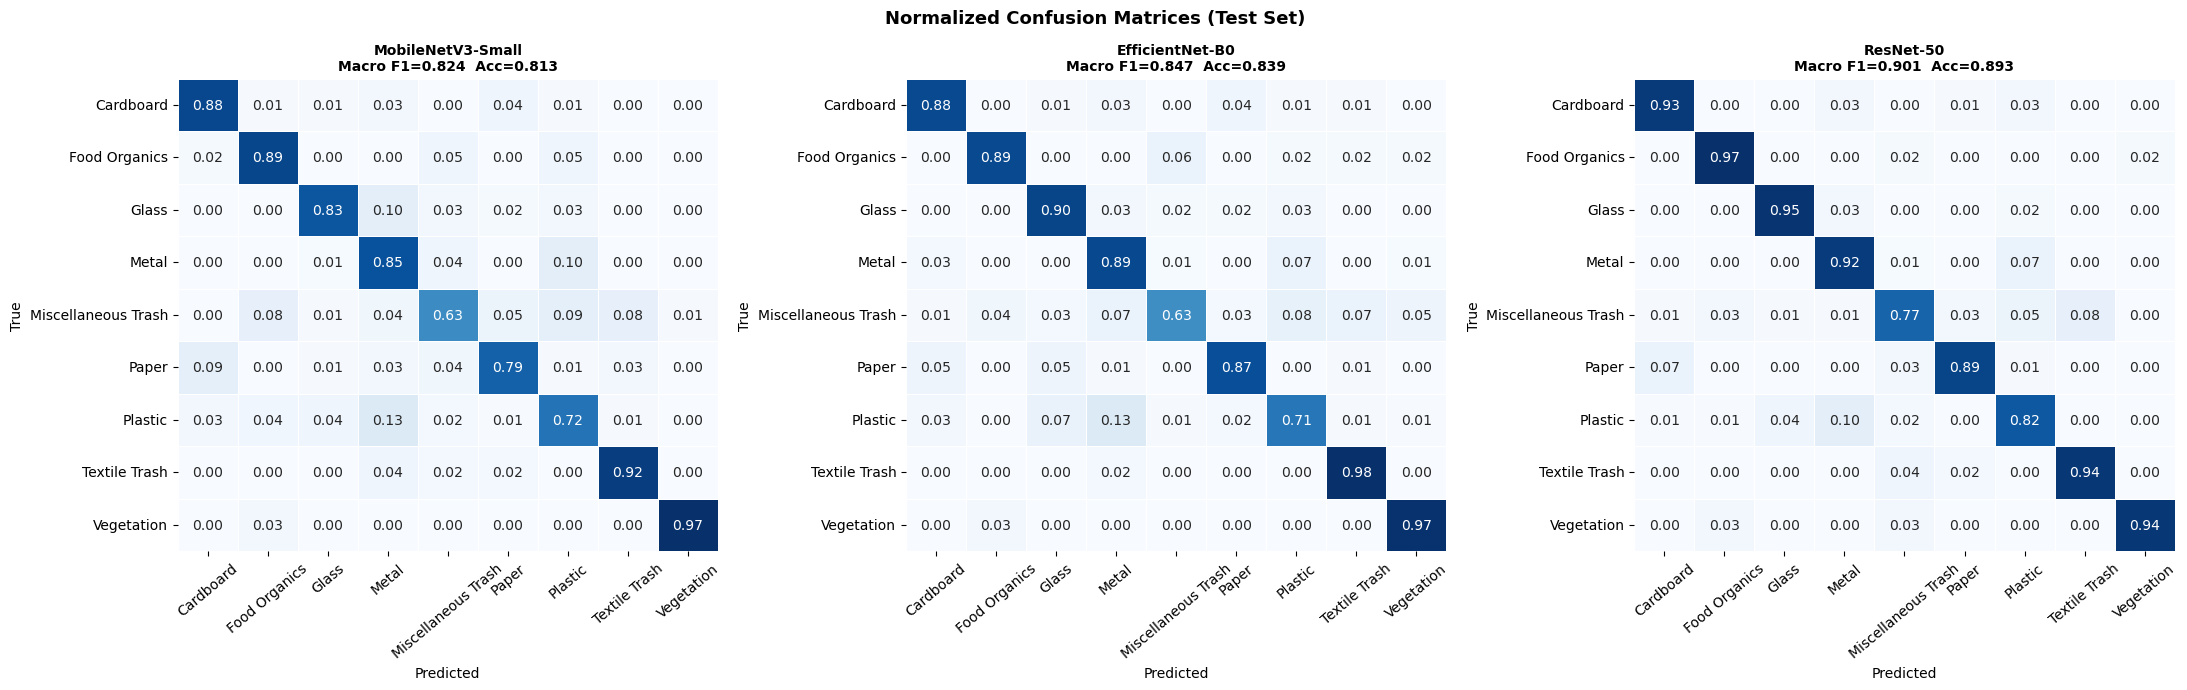

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (model_name, res) in zip(axes, results.items()):
    cm      = confusion_matrix(res['labels'], res['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.4, cbar=False)
    ax.set_title(f'{model_name}\nMacro F1={res["macro_f1"]:.3f}  Acc={res["accuracy"]:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=40)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Normalized Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'confusion_matrices.png'), dpi=150)
plt.show()

### 9c. Model Comparison: Accuracy, F1, and Speed

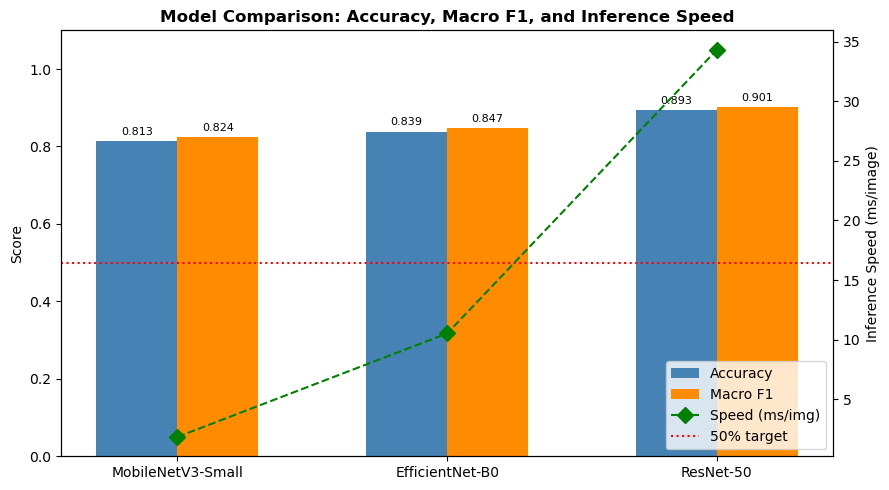

In [17]:
model_names = list(results.keys())
speeds      = [results[m]['speed_ms'] for m in model_names]
f1_scores_  = [results[m]['macro_f1'] for m in model_names]
accuracies  = [results[m]['accuracy'] for m in model_names]
x = np.arange(len(model_names))
width = 0.3

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, accuracies, width, label='Accuracy',   color='steelblue')
bars2 = ax1.bar(x + width/2, f1_scores_, width, label='Macro F1',   color='darkorange')
line  = ax2.plot(x, speeds, 'D--', color='green', label='Speed (ms/img)', markersize=8)

ax1.set_xticks(x)
ax1.set_xticklabels(model_names)
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.1)
ax1.axhline(0.5, color='red', linestyle=':', label='50% target')
ax2.set_ylabel('Inference Speed (ms/image)')
ax1.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax1.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)

handles = [bars1, bars2] + line + [plt.Line2D([0],[0], color='red', linestyle=':')]
ax1.legend(handles, ['Accuracy', 'Macro F1', 'Speed (ms/img)', '50% target'], loc='lower right')

plt.title('Model Comparison: Accuracy, Macro F1, and Inference Speed', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'model_comparison.png'), dpi=150)
plt.show()

## 10. Summary Table & Hypothesis Check

In [19]:
summary_lines = []
summary_lines.append(f'{"Model":<22} {"Accuracy":>10} {"Macro F1":>10} {"Speed (ms/img)":>16}')
summary_lines.append('-' * 62)
for model_name, res in results.items():
    summary_lines.append(f'{model_name:<22} {res["accuracy"]:>10.4f} {res["macro_f1"]:>10.4f} {res["speed_ms"]:>16.3f}')
summary_lines.append('-' * 62)

best_acc_model = max(results, key=lambda m: results[m]['accuracy'])
best_f1_model  = max(results, key=lambda m: results[m]['macro_f1'])
best_spd_model = min(results, key=lambda m: results[m]['speed_ms'])
goal_met       = any(res['accuracy'] >= 0.50 for res in results.values())

summary_lines.append(f'\nHypothesis check:')
summary_lines.append(f'  Best Accuracy  : {best_acc_model}')
summary_lines.append(f'  Best Macro F1  : {best_f1_model}')
summary_lines.append(f'  Fastest model  : {best_spd_model}')
summary_lines.append(f'  >=50% goal met : {goal_met}')

summary_text = '\n'.join(summary_lines)
print(summary_text)

summary_path = os.path.join(OUTPUTS_DIR, 'summary_results.txt')
with open(summary_path, 'w') as f:
    f.write(summary_text)
print(f'\nSummary saved to {summary_path}')

Model                    Accuracy   Macro F1   Speed (ms/img)
--------------------------------------------------------------
MobileNetV3-Small          0.8135     0.8240            1.840
EfficientNet-B0            0.8387     0.8469           10.520
ResNet-50                  0.8934     0.9009           34.315
--------------------------------------------------------------

Hypothesis check:
  Best Accuracy  : ResNet-50
  Best Macro F1  : ResNet-50
  Fastest model  : MobileNetV3-Small
  >=50% goal met : True

Summary saved to ../OUTPUTS\summary_results.txt
